In [6]:
# NLP : Natural language processing
import PyPDF2
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

# Télécharger les stopwords de NLTK
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /home/lgiron/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page_num in range(len(reader.pages)):
            page = reader.pages[page_num]
            text += page.extract_text()
    return text


def preprocess_text(text):
    # Supprimer la ponctuation
    text = re.sub(r"[^\w\s]", "", text)
    # Convertir en minuscules
    text = text.lower()
    # Supprimer les mots de liaison
    stop_words = set(stopwords.words("french"))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


def generate_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
        text
    )
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

In [16]:
# Statistiques
import pandas as pd


def get_statistics(text: str) -> pd.DataFrame:
    """
    Calcule les statistiques de base du texte.
    :param text: Le texte à analyser.
    :return: Un dictionnaire contenant le nombre de mots, de phrases et de paragraphes.
    """
    num_words = len(text.split())

    # Moyenne de mots par phrase
    sentences = re.split(r"[.!?]", text)
    num_sentences = len([s for s in sentences if s.strip() != ""])

    return pd.DataFrame(
        {
            "Nombre de mots": num_words,
            "Moyenne de mots par phrase": num_words / num_sentences
            if num_sentences > 0
            else 0,
        },
        index=[0],
    )

In [17]:
# Chemin vers le fichier PDF
pdf_path = "Conditions générales d'utilisations - data.gouv.fr.pdf"

# Extraire le texte du PDF
text = extract_text_from_pdf(pdf_path=pdf_path)

statistiques = get_statistics(text=text)
statistiques

,Nombre de mots,Moyenne de mots par phrase
0,1134,11.454545


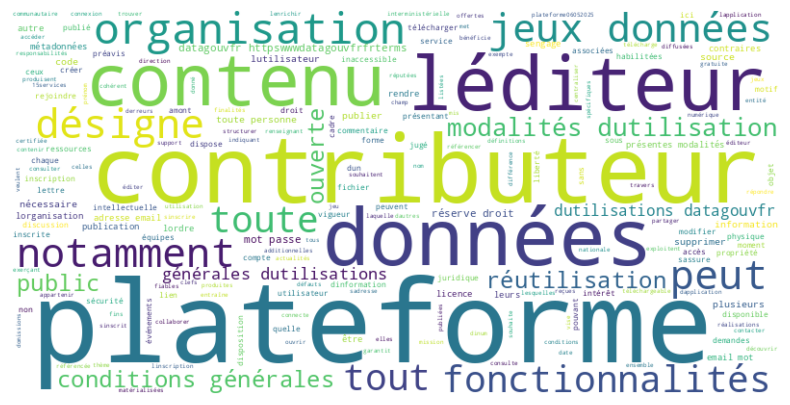

In [18]:
# Prétraiter le texte
processed_text = preprocess_text(text=text)

# Générer et afficher le nuage de mots
generate_wordcloud(text=processed_text)